# MCMC Sample Analysis

End-to-end analysis of the `test_ffi_samples` run using `extract_catalog` + `analyze`.

**Layout on disk:**
```
test_ffi_samples/
├── chain_0/samples/*.parquet   (5 files × 2 samples = 10 samples)
└── chain_1/samples/*.parquet   (5 files × 2 samples = 10 samples)
```
Each sample stores a 64³ initial-condition `DensityField` + full cosmology.


In [1]:
# Must set before any JAX import so the CUDA plugin never attempts to init
import os

os.environ["JAX_PLATFORMS"] = "cpu"

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from jax_fli.infer import analyze, plot_posterior
from jax_fli.io import extract_catalog

## Configuration

In [3]:
SAMPLES_PATH = Path("test_ffi_samples/chain_0")
SAMPLES_PATH = Path("/home/wassim/Projects/NBody/jax_fli/notebooks/output/demo_inference/samples")
OUT_DIR = Path("analyze_output")

# Only Omega_c and sigma8 were sampled in this run; all other cosmological
# parameters are fixed at Planck18 values and must be excluded from the
# pair/rank/trace plots (GetDist and ArviZ require non-zero variance).
COSMO_KEYS = ["Omega_c", "sigma8"]

# LaTeX labels for plots
LABELS = {
    "Omega_c": r"\Omega_c",
    "sigma8": r"\sigma_8",
}

# Fiducial / true cosmology (Planck18-like values used in the run)
TRUTH = {
    "Omega_c": 0.2665945887565613,
    "sigma8": 0.7385836243629456,
}

## 1 — Stream parquet chains and compute statistics

`extract_catalog` reads parquet files one sample at a time (Welford online algorithm), so the full chain never needs to fit in memory. Here we also request per-chain mean and std of the 64³ IC field.

In [4]:
result = extract_catalog(
    str(SAMPLES_PATH),
    set_name="first_set",
    cosmo_keys=COSMO_KEYS,
    field_statistic=True,  # compute per-chain mean and std of the IC field
    power_statistic=False,  # no ground-truth IC available for transfer/coherence
)

print(f"Chains:            {result.n_chains}")
print(f"Samples per chain: {result.cosmo['Omega_c'].shape[1]}")
print(f"Cosmo keys:        {result.cosmo_keys}")
print(f"mean_field shape:  {result.mean_field.array.shape}")
print(f"std_field shape:   {result.std_field.array.shape}")

Chains:            1
Samples per chain: 2
Cosmo keys:        ['Omega_c', 'sigma8']
mean_field shape:  (1, 4, 4, 4)
std_field shape:   (1, 4, 4, 4)


## 2 — Quick per-parameter chain trace

A fast sanity check before running the full report: do the chains explore the same region?

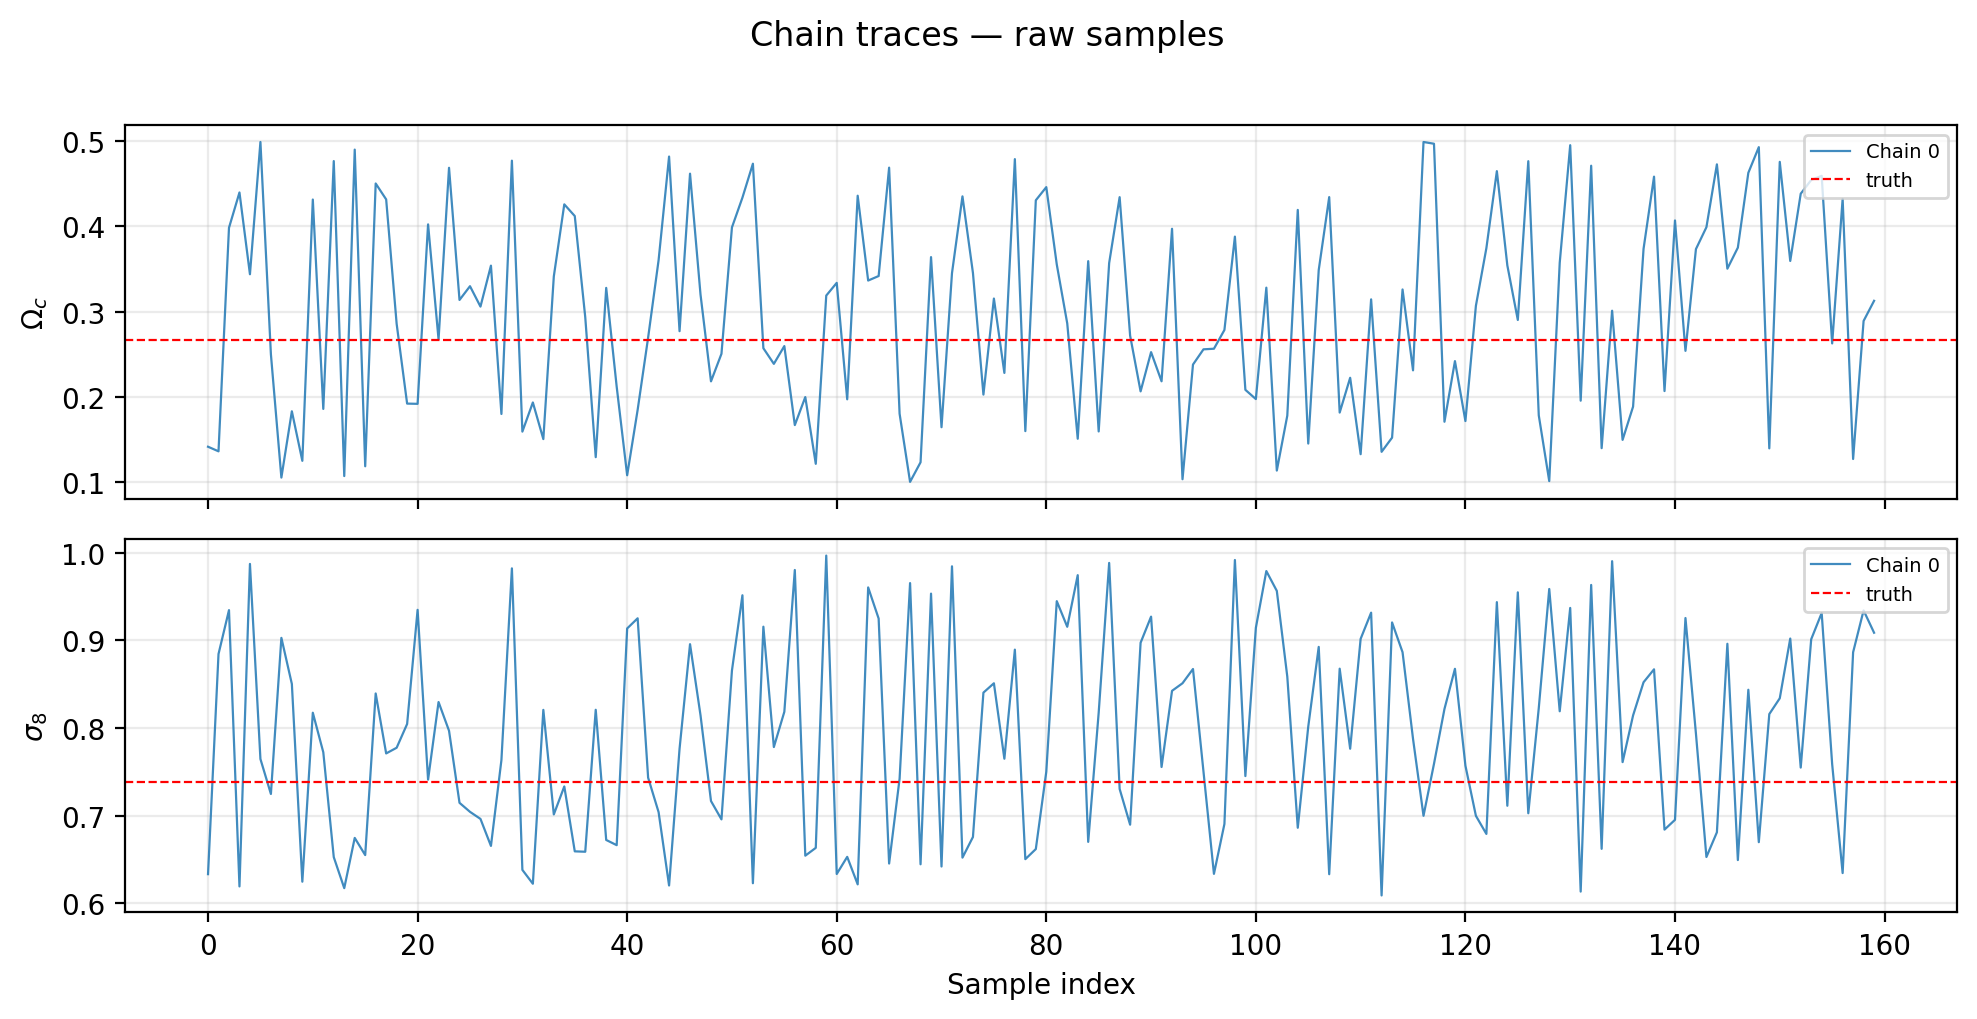

In [20]:
n_params = len(COSMO_KEYS)
fig, axes = plt.subplots(n_params, 1, figsize=(10, 2.5 * n_params), sharex=True)

for ax, key in zip(axes, COSMO_KEYS):
    for c in range(result.n_chains):
        ax.plot(result.cosmo[key][c], lw=0.8, alpha=0.85, label=f"Chain {c}")
    if TRUTH and key in TRUTH:
        ax.axhline(TRUTH[key], color="red", ls="--", lw=0.8, label="truth")
    ax.set_ylabel(f"${LABELS[key]}$")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Sample index")
plt.suptitle("Chain traces — raw samples", y=1.01)
plt.tight_layout()
plt.show()

## 3 — Quick look at per-chain cosmology distributions

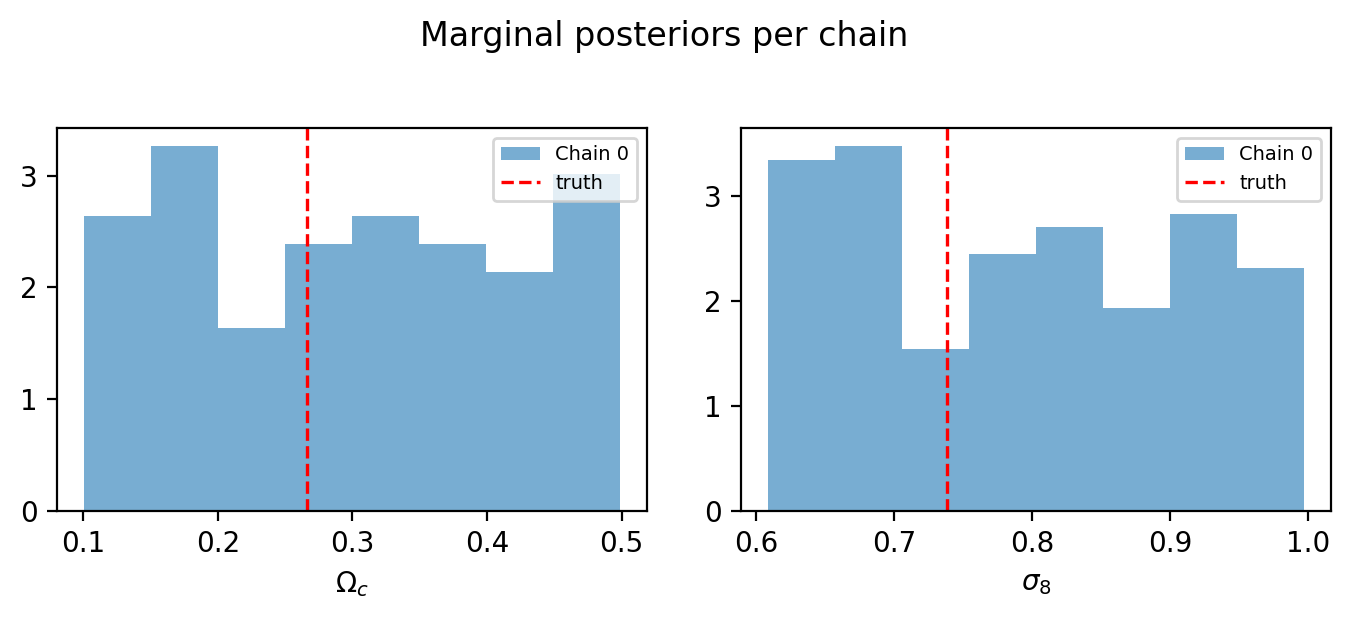

In [21]:
fig, axes = plt.subplots(1, n_params, figsize=(3.5 * n_params, 3))

for ax, key in zip(axes, COSMO_KEYS):
    for c in range(result.n_chains):
        samples = result.cosmo[key][c]
        ax.hist(samples, bins=8, alpha=0.6, label=f"Chain {c}", density=True)
    if TRUTH and key in TRUTH:
        ax.axvline(TRUTH[key], color="red", ls="--", lw=1.2, label="truth")
    ax.set_xlabel(f"${LABELS[key]}$")
    ax.legend(fontsize=7)

plt.suptitle("Marginal posteriors per chain", y=1.02)
plt.tight_layout()
plt.show()

## 4 — IC field projections (mean & std per chain)

Project the mean and std of the 64³ initial-condition field along the z-axis for each chain.

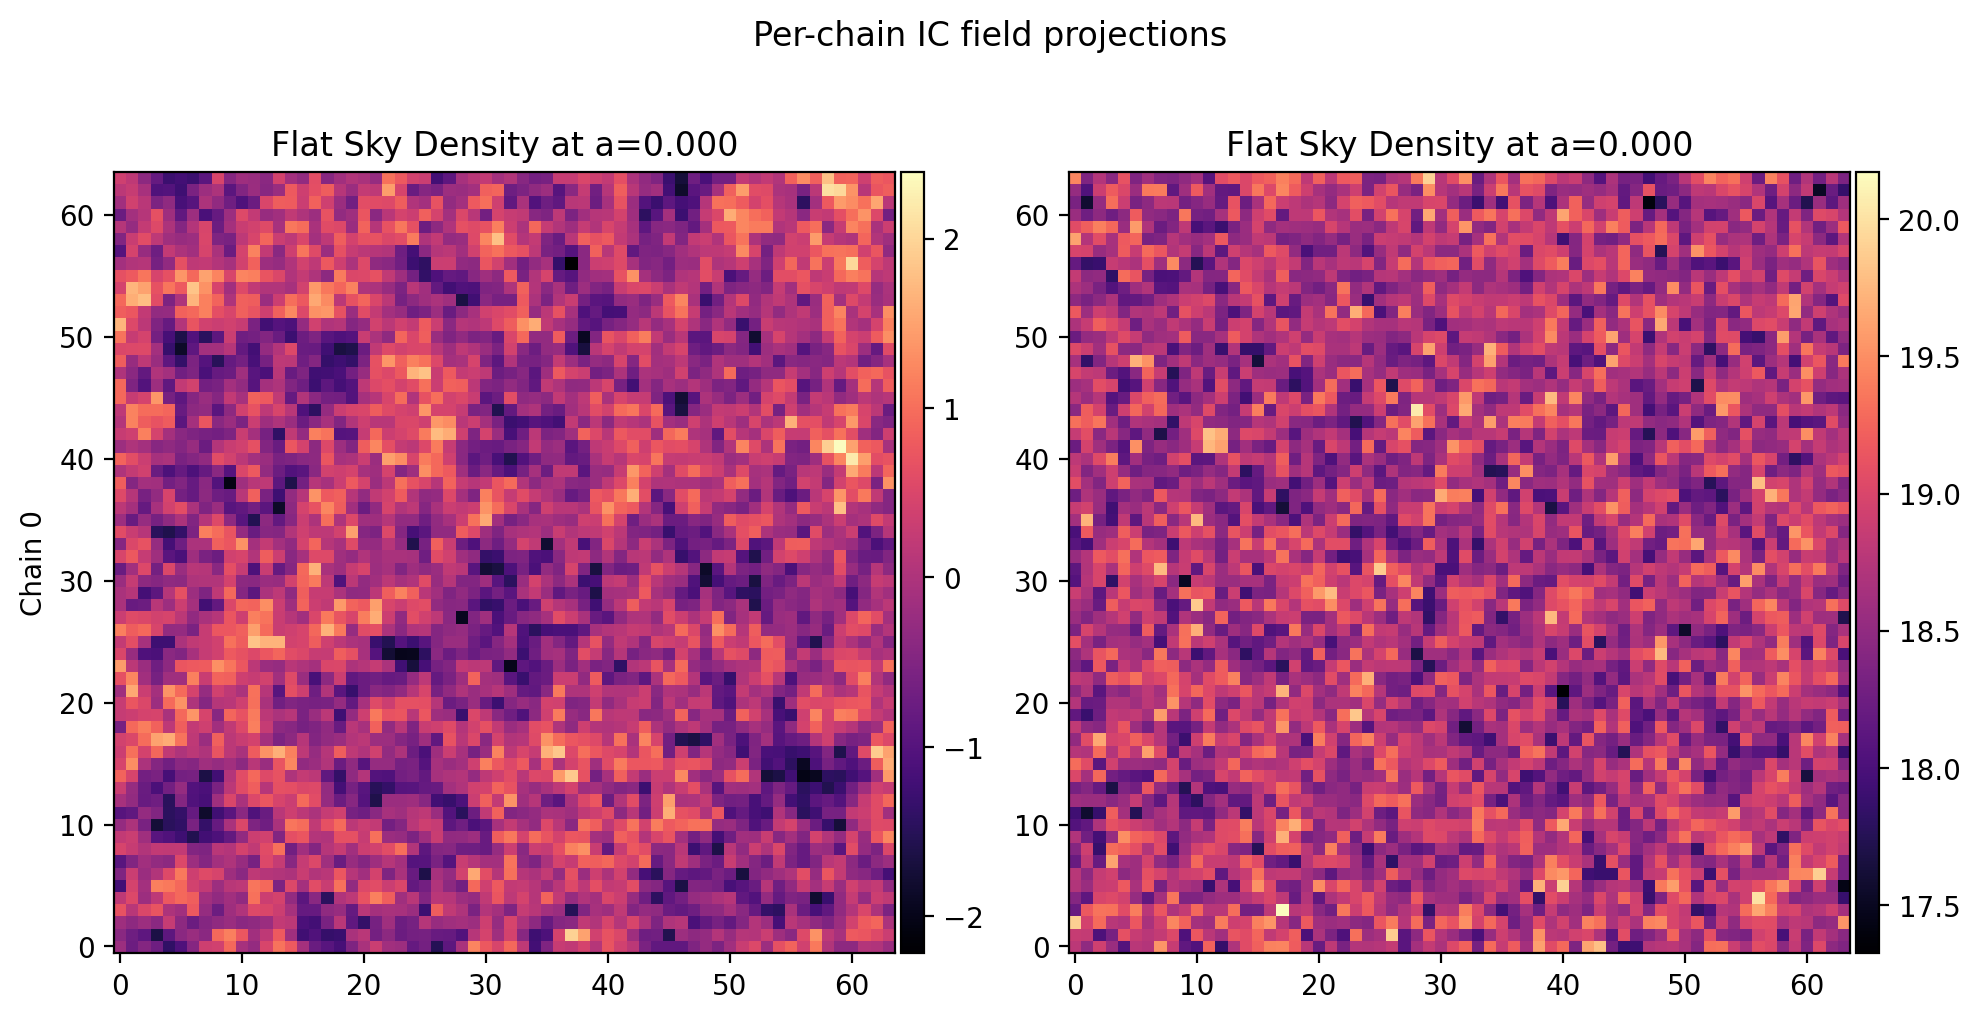

In [22]:
n_chains = result.n_chains
fig, axes = plt.subplots(n_chains, 2, figsize=(10, 5 * n_chains))
if n_chains == 1:
    axes = axes[np.newaxis, :]

axes[0, 0].set_title("Mean IC")
axes[0, 1].set_title("Std IC")

for c in range(n_chains):
    axes[c, 0].set_ylabel(f"Chain {c}")

    mean_c = result.mean_field.replace(array=result.mean_field.array[c])
    std_c = result.std_field.replace(array=result.std_field.array[c])

    mean_c.project().plot(ax=axes[c, 0])
    std_c.project().plot(ax=axes[c, 1])

plt.suptitle("Per-chain IC field projections", y=1.01)
plt.tight_layout()
plt.show()

## 5 — Full report via `analyze()`

`analyze()` writes per-model diagnostic outputs to `OUT_DIR`:

| File | Content |
|---|---|
| `field_projections_model_0.png` | True / Mean / Std / Diff panels |
| `rank_plot_model_0.png` | ArviZ rank diagnostic |
| `trace_plot_model_0.png` | ArviZ chain traces |
| `summary.md` | ESS, R-hat, mean, sd table |

For the triangle plot call `plot_posterior()` separately (see below).

In [23]:
analyze(
    [result],
    outfolder=str(OUT_DIR),
    outformat="png",
    dpi=150,
    labels=LABELS,
    truth=TRUTH,
)
print("Report written to:", OUT_DIR.resolve())
print("Files:", [f.name for f in sorted(OUT_DIR.iterdir())])

Shape validation failed: input_shape: (1, 160), minimum_shape: (chains=2, draws=4)


Report written to: /home/wassim/Projects/NBody/jax_fli/simulations/analyze_output
Files: ['field_projections_model_0.png', 'rank_plot_model_0.png', 'summary.md', 'trace_plot_model_0.png']


### Field projections

### Posterior triangle plot

`plot_posterior()` builds the GetDist triangle plot independently of `analyze()`.
This separation allows multi-model overlays to be composed manually.

Removed no burn in


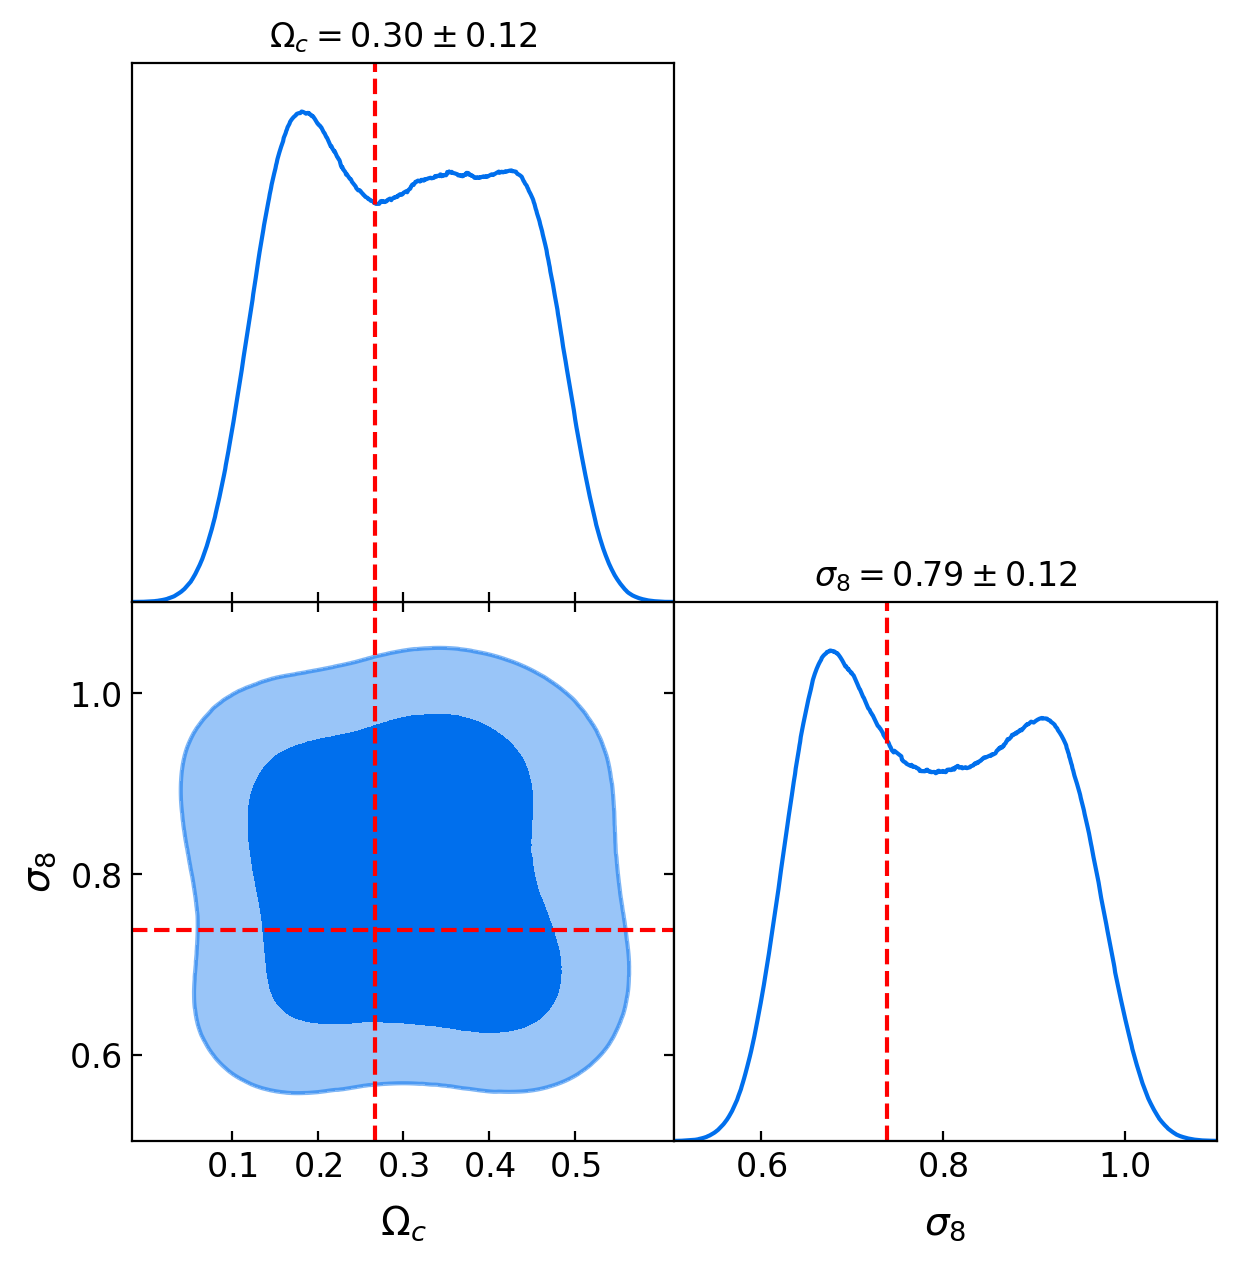

In [24]:
plot_posterior(
    [result],
    labels=LABELS,
    truth=TRUTH,
    dpi=150,
)

In [ ]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import os
import sys

sys.path.insert(0, os.path.realpath(os.path.join(os.getcwd(), "..")))
import getdist
import matplotlib
import matplotlib.pyplot as plt
from getdist import MCSamples, plots

print(f"GetDist Version: {getdist.__version__}, Matplotlib version: {matplotlib.__version__}")

import numpy as np

ndim = 4
nsamp = 100
random_state = np.random.default_rng(10)  # seed random generator
A = random_state.random((ndim, ndim))
cov = np.dot(A, A.T)
samps = random_state.multivariate_normal([0] * ndim, cov, size=nsamp)
A = random_state.random((ndim, ndim))
cov = np.dot(A, A.T)
samps2 = random_state.multivariate_normal([0] * ndim, cov, size=nsamp)

# Get the getdist MCSamples objects for the samples, specifying same parameter
# names and labels; if not specified weights are assumed to all be unity
names = [f"x{i}" for i in range(ndim)]
labels = [f"x_{i}" for i in range(ndim)]
samples = MCSamples(samples=samps, names=names, labels=labels)
samples2 = MCSamples(samples=samps2, names=names, labels=labels, label="Second set")


# Triangle plot (sometimes also called a corner plot)
g = plots.get_subplot_plotter()
g.triangle_plot([samples, samples2], filled=True)

### ArviZ rank plot

In [ ]:
Image(str(OUT_DIR / "rank_plot.png"))

### ArviZ trace plot

In [ ]:
Image(str(OUT_DIR / "trace_plot.png"))

### MCMC Summary table

In [ ]:
from IPython.display import Markdown

Markdown((OUT_DIR / "summary.md").read_text())